# Code Appendix: Hospital Length of Stay Prediction

**Note:** These codes were run in Lightning AI platform for training and evaluating machine learning models to predict hospital length of stay.


In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.impute import SimpleImputer

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# LOAD DATA + CLEAN TARGET VARIABLE IN LIGHTING AI PLATFORM
hospital_df = pd.read_csv("Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2021_20251019.csv")

print(f"Dataset shape: {hospital_df.shape}")
print(f"Total records: {len(hospital_df):,}\n")

# Clean Length of Stay target
hospital_df["Length of Stay"] = hospital_df["Length of Stay"].replace('120 +', 120)
hospital_df["Length of Stay"] = pd.to_numeric(hospital_df["Length of Stay"], errors='coerce')
hospital_df = hospital_df[hospital_df['Patient Disposition'] != "Expired"]
hospital_df = hospital_df[hospital_df["Length of Stay"].notna()]
hospital_df = hospital_df[hospital_df["Length of Stay"] >= 0]

print(f"Records after cleaning: {len(hospital_df):,}")
print(f"\nLOS Statistics:")
print(f"  Mean: {hospital_df['Length of Stay'].mean():.1f} days")
print(f"  Median: {hospital_df['Length of Stay'].median():.1f} days")
print(f"  95th percentile: {hospital_df['Length of Stay'].quantile(0.95):.1f} days")

/var/folders/6l/1tlwwbfx4jncfj1xhbt9dwdw0000gn/T/ipykernel_32015/2705059108.py:2: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  hospital_df = pd.read_csv("Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2021_20251019.csv")


Dataset shape: (2135260, 33)
Total records: 2,135,260

Records after cleaning: 2,070,454

LOS Statistics:
  Mean: 5.5 days
  Median: 3.0 days
  95th percentile: 18.0 days


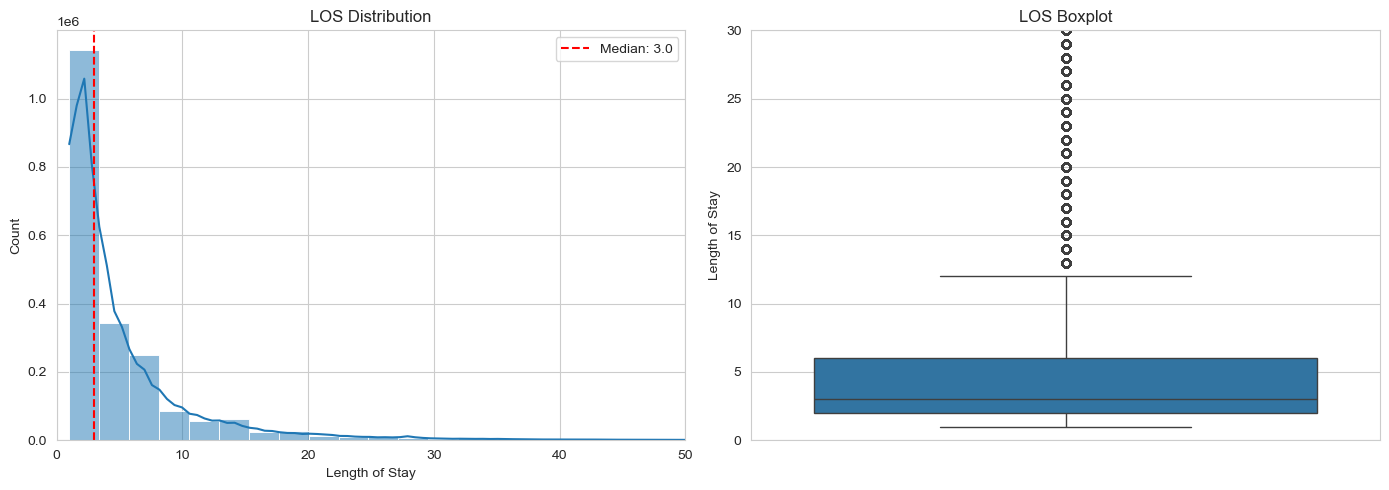

Columns with missing values: 12


,Missing Count,Percentage
Birth Weight,1861039,89.89
Payment Typology 3,1751596,84.60
Payment Typology 2,1073211,51.83
CCSR Procedure Code,573346,27.69
CCSR Procedure Description,573346,27.69
Zip Code - 3 digits,39108,1.89
Operating Certificate Number,6600,0.32
Hospital County,5167,0.25
Hospital Service Area,5167,0.25
Permanent Facility Id,5167,0.25


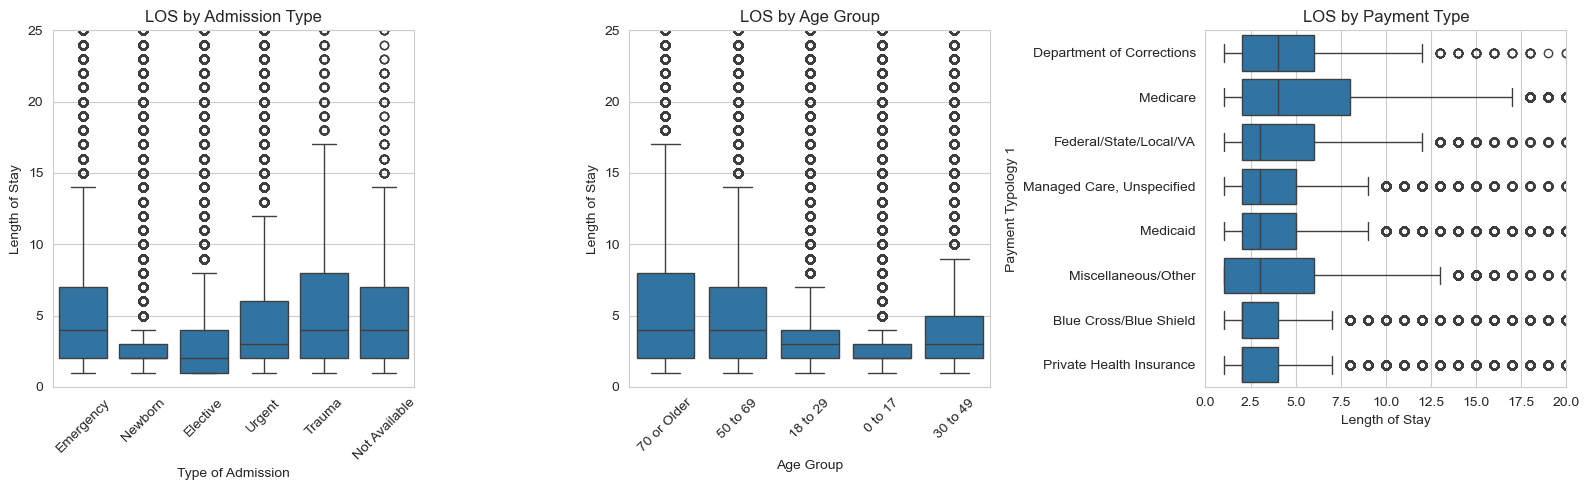

In [3]:
# EDA

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(hospital_df['Length of Stay'], bins=50, kde=True, ax=axes[0])
axes[0].set_xlim(0, 50)
axes[0].axvline(hospital_df['Length of Stay'].median(), color='red', linestyle='--', 
                label=f'Median: {hospital_df["Length of Stay"].median():.1f}')
axes[0].legend()
axes[0].set_title("LOS Distribution")

sns.boxplot(y=hospital_df['Length of Stay'], ax=axes[1])
axes[1].set_ylim(0, 30)
axes[1].set_title("LOS Boxplot")
plt.tight_layout()
plt.show()

# Missing values
missing = hospital_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(hospital_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print(f"Columns with missing values: {len(missing_df)}")
display(missing_df.head(10))

# Key relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=hospital_df, x="Type of Admission", y="Length of Stay", ax=axes[0])
axes[0].set_ylim(0, 25)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("LOS by Admission Type")

sns.boxplot(data=hospital_df, x='Age Group', y='Length of Stay', ax=axes[1])
axes[1].set_ylim(0, 25)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("LOS by Age Group")

payment_order = hospital_df.groupby('Payment Typology 1')['Length of Stay'].median().sort_values(ascending=False).index[:8]
sns.boxplot(data=hospital_df, y='Payment Typology 1', x='Length of Stay', order=payment_order, ax=axes[2])
axes[2].set_xlim(0, 20)
axes[2].set_title("LOS by Payment Type")

plt.tight_layout()
plt.show()

In [4]:
# DROP IRRELEVANT COLUMNS
columns_to_drop = [
    'Hospital Service Area', 'Hospital County', 'Operating Certificate Number',
    "Facility Name", "Zip Code - 3 digits", "Patient Disposition", "Discharge Year",
    "CCSR Diagnosis Description", "CCSR Procedure Description", "APR DRG Description",
    "APR MDC Description", "APR Severity of Illness Description",
    "Payment Typology 2", "Payment Typology 3", "Birth Weight",
    "Total Charges", "Total Costs"  # Leakage - calculated after discharge
]
columns_to_drop = [col for col in columns_to_drop if col in hospital_df.columns]
hospital_df = hospital_df.drop(columns_to_drop, axis=1)

print(f"Features remaining: {hospital_df.shape[1] - 1}")  # -1 for target
print(f"Columns: {list(hospital_df.columns)}")

Features remaining: 15
Columns: ['Permanent Facility Id', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission', 'CCSR Diagnosis Code', 'CCSR Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Emergency Department Indicator']


In [5]:
# TRAIN-TEST SPLIT (BEFORE ENCODING - PREVENTS DATA LEAKAGE)
X = hospital_df.drop("Length of Stay", axis=1)
y = hospital_df["Length of Stay"]

# Stratified split by LOS bins
y_bins = pd.cut(y, bins=[0, 2, 5, 10, 20, np.inf],
                labels=['0-2', '3-5', '6-10', '11-20', '20+'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_bins
)

print(f"Training: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training: 1,656,363 samples (80.0%)
Test: 414,091 samples (20.0%)


In [6]:
# PREPROCESSING PIPELINE

# Identify feature types
ordinal_features = ['Age Group', 'APR Risk of Mortality', 'APR Severity of Illness Code']
ordinal_features = [col for col in ordinal_features if col in X_train.columns]

nominal_features = [
    'Gender', 'Race', 'Ethnicity', 'Type of Admission',
    'APR Medical Surgical Description', 'Payment Typology 1',
    'Emergency Department Indicator'
]
nominal_features = [col for col in nominal_features if col in X_train.columns]

# Add categorical code columns (CCSR, APR DRG, etc.) to nominal
code_features = []
for col in X_train.columns:
    if col not in ordinal_features + nominal_features and X_train[col].dtype == 'object':
        code_features.append(col)

all_nominal_features = nominal_features + code_features
numeric_features = [col for col in X_train.columns 
                    if col not in ordinal_features + all_nominal_features]

print(f"Ordinal: {len(ordinal_features)}, Nominal: {len(all_nominal_features)}, Numeric: {len(numeric_features)}")

# Ordinal mappings
age_mapping = [['0 to 17', '18 to 29', '30 to 49', '50 to 69', '70 or Older']]
risk_mapping = [['Minor', 'Moderate', 'Major', 'Extreme']]
severity_mapping = [['1', '2', '3', '4']]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('age', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(categories=age_mapping, handle_unknown='use_encoded_value', unknown_value=-1))
        ]), ['Age Group']),
        
        ('risk', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(categories=risk_mapping, handle_unknown='use_encoded_value', unknown_value=-1))
        ]), ['APR Risk of Mortality']),
        
        ('severity', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(categories=severity_mapping, handle_unknown='use_encoded_value', unknown_value=-1))
        ]), ['APR Severity of Illness Code']),
        
        ('nominal', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), all_nominal_features),
        
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('passthrough', 'passthrough')
        ]), numeric_features)
    ],
    remainder='drop'
)

print("Preprocessing pipeline created")

Ordinal: 3, Nominal: 9, Numeric: 3
Preprocessing pipeline created


In [7]:
# MODEL PIPELINES + CUSTOM SCORING

# Custom scoring: accuracy within ±1 day
def regression_accuracy(y_true, y_pred, tolerance=1):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= tolerance)

accuracy_1day_scorer = make_scorer(
    lambda y_true, y_pred: regression_accuracy(y_true, y_pred, tolerance=1),
    greater_is_better=True
)

# Create model pipelines
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=5000))
])

tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

print("model pipelines created")

model pipelines created


In [8]:
# HYPERPARAMETER TUNING
print("Training models (this may take 15-30 minutes)...\n")

# Linear Regression
print("1. Linear Regression...")
linear_pipeline.fit(X_train, y_train)
print(" Complete\n")

# Ridge
print("2. Ridge Regression...")
ridge_grid = GridSearchCV(
    ridge_pipeline,
    {'model__alpha': [0.1, 1, 10, 100]},
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=1,
    verbose=1
)
ridge_grid.fit(X_train, y_train)
print(f" Best alpha: {ridge_grid.best_params_['model__alpha']}\n")

# Lasso
print("3. Lasso Regression...")
lasso_grid = GridSearchCV(
    lasso_pipeline,
    {'model__alpha': [0.001, 0.01, 0.1, 1]},
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=1,
    verbose=1
)
lasso_grid.fit(X_train, y_train)
print(f"Best alpha: {lasso_grid.best_params_['model__alpha']}\n")

# Decision Tree
print("4. Decision Tree...")
tree_grid = GridSearchCV(
    tree_pipeline,
    {'model__max_depth': [10, 20, None], 'model__min_samples_split': [10, 50]},
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=1,
    verbose=1
)
tree_grid.fit(X_train, y_train)
print(f"Best params: {tree_grid.best_params_}\n")

print("All models trained successfully")

Training models (this may take 15-30 minutes)...

1. Linear Regression...


In [ ]:
# MODEL EVALUATION
models = {
    "Linear Regression": linear_pipeline,
    "Ridge Regression": ridge_grid.best_estimator_,
    "Lasso Regression": lasso_grid.best_estimator_,
    "Decision Tree": tree_grid.best_estimator_
}

# Calculate train and test results
results_train = {}
results_test = {}

for name, model in models.items():
    # Train predictions
    y_train_pred = model.predict(X_train)
    results_train[name] = [
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        r2_score(y_train, y_train_pred),
        regression_accuracy(y_train, y_train_pred, 1),
        regression_accuracy(y_train, y_train_pred, 2)
    ]

    # Test predictions
    y_test_pred = model.predict(X_test)
    results_test[name] = [
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        r2_score(y_test, y_test_pred),
        regression_accuracy(y_test, y_test_pred, 1),
        regression_accuracy(y_test, y_test_pred, 2)
    ]

results_train_df = pd.DataFrame(
    results_train,
    index=["MAE (days)", "RMSE (days)", "R²", "Acc ±1 day", "Acc ±2 days"]
).T

results_test_df = pd.DataFrame(
    results_test,
    index=["MAE (days)", "RMSE (days)", "R²", "Acc ±1 day", "Acc ±2 days"]
).T

print("\nTrain Set Results:")
display(results_train_df.round(4))

print("\nTest Set Results:")
display(results_test_df.round(4))

best_model = results_test_df['MAE (days)'].idxmin()
print(f"\nBest Model: {best_model}")
print(f"MAE: {results_test_df.loc[best_model, 'MAE (days)']:.3f} days")
print(f"Accuracy ±1 day: {results_test_df.loc[best_model, 'Acc ±1 day']:.1%}")

# Train vs Test comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# MAE comparison
mae_comp = pd.DataFrame({
    'Train': results_train_df['MAE (days)'],
    'Test': results_test_df['MAE (days)']
})
mae_comp.plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'])
axes[0, 0].set_ylabel('MAE (days)')
axes[0, 0].set_title('Mean Absolute Error - Train vs Test')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].legend(['Train', 'Test'])

# R² comparison
r2_comp = pd.DataFrame({
    'Train': results_train_df['R²'],
    'Test': results_test_df['R²']
})
r2_comp.plot(kind='bar', ax=axes[0, 1], color=['steelblue', 'coral'])
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('R² Score - Train vs Test')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].legend(['Train', 'Test'])

# Accuracy ±1 day
acc1_comp = pd.DataFrame({
    'Train': results_train_df['Acc ±1 day'],
    'Test': results_test_df['Acc ±1 day']
})
acc1_comp.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'coral'])
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy Within ±1 Day - Train vs Test')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].legend(['Train', 'Test'])

# Accuracy ±2 days
acc2_comp = pd.DataFrame({
    'Train': results_train_df['Acc ±2 days'],
    'Test': results_test_df['Acc ±2 days']
})
acc2_comp.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'coral'])
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Accuracy Within ±2 Days - Train vs Test')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend(['Train', 'Test'])

plt.tight_layout()
plt.show()

In [ ]:
# FEATURE IMPORTANCE (BEST MODEL)
best_model_name = results_test_df['MAE (days)'].idxmin()
best_model = models[best_model_name]

# Get feature names
try:
    onehot_features = best_model.named_steps['preprocessor'].named_transformers_['nominal'].get_feature_names_out(all_nominal_features).tolist()
except:
    onehot_features = []

feature_names = ordinal_features + onehot_features + numeric_features

# Extract importance
if best_model_name == "Decision Tree":
    importances = best_model.named_steps['model'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 20 Features - {best_model_name}")
    display(importance_df.head(20))
    
    plt.figure(figsize=(10, 8))
    top = importance_df.head(20)
    plt.barh(range(len(top)), top['Importance'])
    plt.yticks(range(len(top)), top['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    coefficients = best_model.named_steps['model'].coef_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Importance': np.abs(coefficients)
    }).sort_values('Abs_Importance', ascending=False)
    
    print(f"\nTop 20 Features - {best_model_name}")
    display(importance_df.head(20))
    
    plt.figure(figsize=(10, 8))
    top = importance_df.head(20)
    colors = ['green' if x > 0 else 'red' for x in top['Coefficient']]
    plt.barh(range(len(top)), top['Coefficient'], color=colors, alpha=0.7)
    plt.yticks(range(len(top)), top['Feature'])
    plt.xlabel('Coefficient')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.title(f'Top 20 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [ ]:
# SUMMARY & EXPORT
best_model_name = results_test_df['MAE (days)'].idxmin()

print("FINAL SUMMARY")
print(f"\nBest Model: {best_model_name}")
print(f"\nTest Performance:")
print(f"  MAE:  {results_test_df.loc[best_model_name, 'MAE (days)']:.3f} days")
print(f"  RMSE: {results_test_df.loc[best_model_name, 'RMSE (days)']:.3f} days")
print(f"  R²:   {results_test_df.loc[best_model_name, 'R²']:.4f}")
print(f"  Accuracy ±1 day: {results_test_df.loc[best_model_name, 'Acc ±1 day']:.1%}")
print(f"  Accuracy ±2 days: {results_test_df.loc[best_model_name, 'Acc ±2 days']:.1%}")

print(f"\nDataset:")
print(f"  Total records: {len(hospital_df):,}")
print(f"  Training: {len(X_train):,}")
print(f"  Test: {len(X_test):,}")

# Export results
results_train_df.to_csv('model_performance_train.csv')
results_test_df.to_csv('model_performance_test.csv')
if 'importance_df' in globals():
    importance_df.to_csv('feature_importance.csv', index=False)

print("\nResults exported")